# A_4_2 — Semantic clustering (Sentence Transformers, UMAP, HDBSCAN)

**Input:** `Results/Delay_reason_only*.xlsx`
**Output:** `Results/Clusters_Delayed_HDBSCAN.xlsx`, `Results/Clusters_Rescheduled_HDBSCAN.xlsx` (SI Figs 3–4)

Statements with the same meaning are often worded differently, so each is
encoded with a sentence-transformer model, reduced with UMAP and clustered with
HDBSCAN, which assigns uninformative statements to a noise category rather than
forcing them into a cluster. UMAP and HDBSCAN parameters are grid-searched and
ranked by silhouette score; the configuration used is selected among the
top-ranked solutions for thematic interpretability.

Cluster keywords and example statements are extracted to define the expert
taxonomy applied in A_4_3.

In [2]:
import os
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer


In [3]:
warnings.filterwarnings(
    "ignore",
    message="n_jobs value.*overridden to 1 by setting random_state"
)

warnings.filterwarnings("ignore", category=FutureWarning)

### Delay

In [4]:
df_delayed = pd.read_excel("Results/Delay_reason_onlyDelayed.xlsx")

df_delayed = df_delayed.dropna(subset=['Inv_Progress Driver'])
df_delayed['Inv_Progress Driver'] = df_delayed['Inv_Progress Driver'].astype(str)

sentences = df_delayed['Inv_Progress Driver'].tolist()
print(f"Successfully loaded {len(sentences)} sentences for the 'Delayed' analysis.")

Successfully loaded 479 sentences for the 'Delayed' analysis.


### Step 1: Cluster Delayed items

In [5]:
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

embedder = SentenceTransformer('all-MiniLM-L6-v2')
texts_delayed = df_delayed['Inv_Progress Driver'].tolist()
embs_delayed = embedder.encode(texts_delayed, show_progress_bar=False)

param_grid = {
    'n_neighbors':      [5, 15, 30],
    'min_dist':         [0.0, 0.1, 0.3],
    'min_cluster_size': [10, 15, 20, 25],
    'cluster_eps':      [0.0, 0.05, 0.1]
}

best_score = -1
best_cfg   = None

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [6]:
results = []
best_score = -1
best_labels = None
best_umap_emb = None
best_cfg = None


for nn in param_grid['n_neighbors']:
    for md in param_grid['min_dist']:
        umap_emb = umap.UMAP(
            n_neighbors=nn, min_dist=md, metric='cosine', random_state=42
        ).fit_transform(embs_delayed)

        for mcs in param_grid['min_cluster_size']:
            for eps in param_grid['cluster_eps']:
                labels = hdbscan.HDBSCAN(
                    min_cluster_size=mcs,
                    cluster_selection_epsilon=eps,
                    metric='euclidean'
                ).fit_predict(umap_emb)

                mask = labels >= 0
                if mask.sum() > 1 and len(np.unique(labels[mask])) > 1:
                    score = silhouette_score(umap_emb[mask], labels[mask])
                    results.append((score, nn, md, mcs, eps))
                    
                    if score > best_score:
                        best_score = score
                        best_labels = labels
                        best_umap_emb = umap_emb
                        best_cfg = {'n_neighbors': nn, 'min_dist': md, 'min_cluster_size': mcs, 'cluster_eps': eps}

results = sorted(results, key=lambda x: x[0], reverse=True)
top10 = results[:10]

print("\nTop 10 Delayed configs by silhouette:")
for rank, (score, nn, md, mcs, eps) in enumerate(top10, 1):
    print(f"{rank:2d}. silhouette={score:.4f} -> "
          f"n_neighbors={nn}, min_dist={md}, "
          f"min_cluster_size={mcs}, eps={eps}")

C:\Users\damia\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(



Top 10 Delayed configs by silhouette:
 1. silhouette=0.7501 -> n_neighbors=15, min_dist=0.0, min_cluster_size=10, eps=0.0
 2. silhouette=0.7501 -> n_neighbors=15, min_dist=0.0, min_cluster_size=10, eps=0.05
 3. silhouette=0.7501 -> n_neighbors=15, min_dist=0.0, min_cluster_size=10, eps=0.1
 4. silhouette=0.7446 -> n_neighbors=30, min_dist=0.0, min_cluster_size=10, eps=0.0
 5. silhouette=0.7446 -> n_neighbors=30, min_dist=0.0, min_cluster_size=10, eps=0.05
 6. silhouette=0.7446 -> n_neighbors=30, min_dist=0.0, min_cluster_size=10, eps=0.1
 7. silhouette=0.7097 -> n_neighbors=15, min_dist=0.1, min_cluster_size=10, eps=0.0
 8. silhouette=0.7097 -> n_neighbors=15, min_dist=0.1, min_cluster_size=10, eps=0.05
 9. silhouette=0.7097 -> n_neighbors=15, min_dist=0.1, min_cluster_size=10, eps=0.1
10. silhouette=0.7068 -> n_neighbors=5, min_dist=0.0, min_cluster_size=10, eps=0.0


### Silhouette Score

The **silhouette score** is a measure of how well your clustering has performed—specifically, how **cohesive** each cluster is internally, and how **separated** it is from its nearest‐neighbor cluster.

For each sample \(i\) in cluster \(A\):

1. **Cohesion** \(a(i)\)  
   The average distance from \(i\) to all other points in the **same** cluster \(A\).

2. **Separation** \(b(i)\)  
   The lowest average distance from \(i\) to all points in **any other** cluster \(B \neq A\).

3. **Silhouette for point** \(i\)  
   \[
     s(i)\;=\;\frac{b(i) \;-\; a(i)}{\max\{a(i),\,b(i)\}}
     \quad\in [-1, 1]
   \]  
   - \(s(i)\approx +1\) → point is well matched to its own cluster and far from others  
   - \(s(i)\approx 0\) → point lies on or very close to the decision boundary between two clusters  
   - \(s(i)\approx -1\) → point may have been assigned to the wrong cluster

4. **Overall silhouette score**  
   The mean of \(s(i)\) over all samples.

---

### How We Computed It

- **Embedding**:  
  We first reduced the high-dimensional sentence embeddings to 2D via **UMAP**.
- **Clustering**:  
  We then ran **HDBSCAN** on the 2D UMAP embedding to assign cluster labels.
- **Silhouette**:  
  Finally, we computed the silhouette score on the points **within** clusters (excluding HDBSCAN “outliers”) using their 2D UMAP coordinates and the HDBSCAN labels.  


### Step 2: Apply that best config & assign cluster labels

In [7]:
score, nn, md, mcs, eps = top10[4]
print(f"Applying config -> n_neighbors={nn}, min_dist={md}, min_cluster_size={mcs}, eps={eps}")

umap_del = umap.UMAP(
    n_neighbors=nn, min_dist=md, metric='cosine', random_state=42
).fit_transform(embs_delayed)

labels_del = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    cluster_selection_epsilon=eps,
    metric='euclidean'
).fit_predict(umap_del)

df_delayed['Cluster'] = labels_del
df_delayed['Category'] = [
    f"Delayed Cluster {int(l)}" if l >= 0 else "Outlier"
    for l in labels_del
]

print("\nUnique Delayed labels:", np.unique(labels_del))

print("\n--- Items per Cluster ---")
counts = Counter(labels_del)
for lbl, cnt in sorted(counts.items()):
    name = "Outlier" if lbl < 0 else f"Cluster {lbl}"
    print(f"{name}: {cnt} items")

Applying config -> n_neighbors=30, min_dist=0.0, min_cluster_size=10, eps=0.05

Unique Delayed labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]

--- Items per Cluster ---
Outlier: 102 items
Cluster 0: 60 items
Cluster 1: 16 items
Cluster 2: 12 items
Cluster 3: 18 items
Cluster 4: 15 items
Cluster 5: 15 items
Cluster 6: 44 items
Cluster 7: 21 items
Cluster 8: 11 items
Cluster 9: 25 items
Cluster 10: 47 items
Cluster 11: 20 items
Cluster 12: 14 items
Cluster 13: 31 items
Cluster 14: 28 items


### Step 3: Graph of cluster

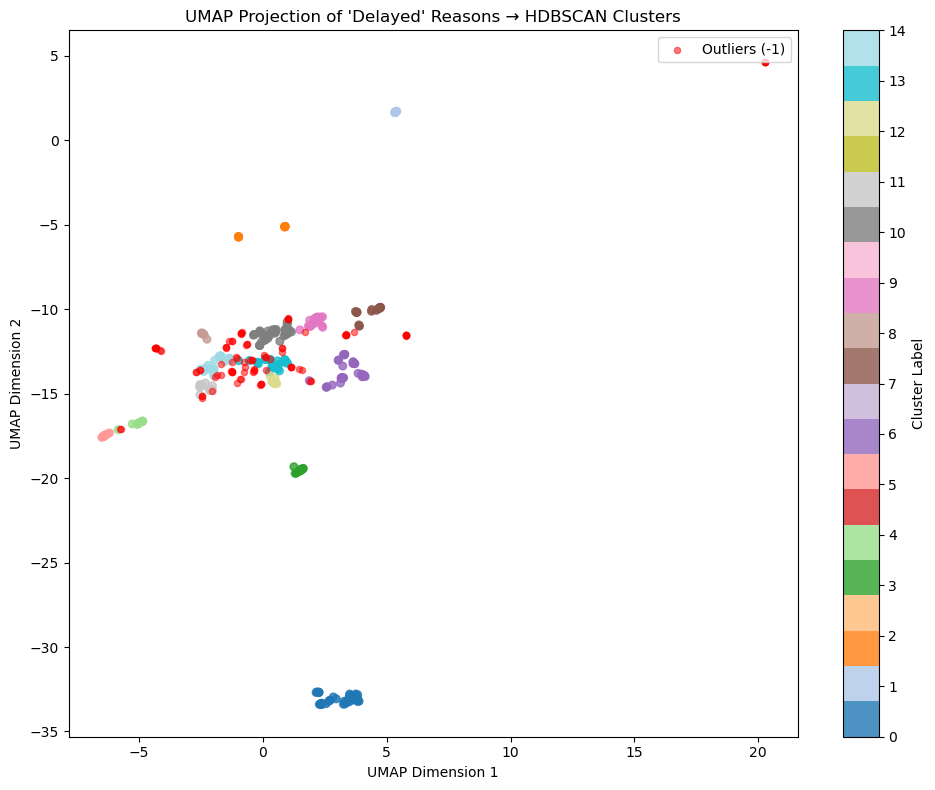

In [8]:
plt.figure(figsize=(10, 8))

mask_out = labels_del == -1
mask_in  = ~mask_out

sc = plt.scatter(
    umap_del[mask_in, 0], 
    umap_del[mask_in, 1], 
    c=labels_del[mask_in],      
    cmap='tab20',               
    s=30,                       
    alpha=0.8                   
)

plt.scatter(
    umap_del[mask_out, 0],
    umap_del[mask_out, 1],
    color='red',
    s=20,                       
    alpha=0.5,                  
    label='Outliers (-1)'
)

plt.legend(loc='upper right')
plt.title("UMAP Projection of 'Delayed' Reasons → HDBSCAN Clusters")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

valid_ticks = np.unique(labels_del[mask_in])
cbar = plt.colorbar(sc, ticks=valid_ticks)
cbar.set_label("Cluster Label")

plt.tight_layout()
plt.savefig("Images/Umap_Delay.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

### Step 4: Generate a human‐readable “meaning” for each Delayed cluster

In [9]:
def top_keywords(texts, top_n=5):
    min_docs = 2 if len(texts) >= 2 else 1
    
    vec = TfidfVectorizer(
        max_df=0.8,       
        min_df=min_docs,  
        stop_words='english'
    )
    X = vec.fit_transform(texts)
    scores = np.asarray(X.sum(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    top_ix = scores.argsort()[::-1][:top_n]
    return [terms[i] for i in top_ix]

def summarize_clusters(df_isolated, embedder, top_n_kw=5):
    print("--- Final Intelligent Cluster Summary ---")
    
    for cl in sorted(df_isolated['Cluster'].unique()):
        docs = df_isolated[df_isolated['Cluster'] == cl]['Inv_Progress Driver'].dropna().astype(str).tolist()
        docs = [d for d in docs if d.strip() != ''] 
        
        if not docs:
            continue
            
        n = len(docs)
        
        if cl < 0:
            print(f"\n[ Outliers (-1) | Total: {n} sentences ]")
            print("Examples of uncategorized sentences:")
            for ex in docs[:3]:
                print(f"  - \"{ex}\"")
            continue

        kws = top_keywords(docs, top_n=top_n_kw)

        embs = embedder.encode(docs, show_progress_bar=False)
        centroid = embs.mean(axis=0)
        idx = np.linalg.norm(embs - centroid, axis=1).argmin()
        rep = docs[idx]

        print(f"\n[ Cluster {cl} | Total: {n} sentences ]")
        print(f"  • Keywords: {', '.join(kws)}")
        print(f"  • Representative: \"{rep}\"")

summarize_clusters(df_delayed, embedder, top_n_kw=5)

--- Final Intelligent Cluster Summary ---

[ Outliers (-1) | Total: 102 sentences ]
Examples of uncategorized sentences:
  - "lines: long permitting procedure (comprising several phases)- Mühleberg substation: under construction"
  - "Previously "mid term" is now updated
to specific date. Partly under construction (section Vieselbach – Altenfeld). 3rd section (Altenfeld – Redwitz) in permitting process, long permitting process with strong public resistance.
"
  - "Due to the expected delay of the connection of new RES generation in North of Portugal, the commissioning date of this investment item is delayed"

[ Cluster 0 | Total: 60 sentences ]
  • Keywords: delay, long, complex, delayed, longer
  • Representative: "Delay due to long permitting process"

[ Cluster 1 | Total: 16 sentences ]
  • Keywords: swiss, progress, negotiations, authorities, advancing
  • Representative: "Awaiting international contracts for renewable energy"

[ Cluster 2 | Total: 12 sentences ]
  • Keywords: nati

In [10]:
output_path_delayed = "Results/Clusters_Delayed_HDBSCAN.xlsx"
df_delayed.to_excel(output_path_delayed, index=False)


### Rescheduled

In [11]:
df_Rescheduled = pd.read_excel("Results/Delay_reason_onlyRescheduled.xlsx")

df_Rescheduled = df_Rescheduled.dropna(subset=['Inv_Progress Driver'])
df_Rescheduled['Inv_Progress Driver'] = df_Rescheduled['Inv_Progress Driver'].astype(str)

sentences = df_Rescheduled['Inv_Progress Driver'].tolist()

print(f"Successfully loaded {len(sentences)} sentences for the 'Rescheduled' analysis.")

Successfully loaded 213 sentences for the 'Rescheduled' analysis.


### Step 1: Cluster Rescheduled items

In [12]:
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

embedder = SentenceTransformer('all-MiniLM-L6-v2')

texts_Rescheduled = df_Rescheduled['Inv_Progress Driver'].tolist()

print("Generating embeddings (this will take a few seconds)...")
embs_Rescheduled = embedder.encode(texts_Rescheduled, show_progress_bar=False)
print("Embeddings generated successfully!")

param_grid = {
    'n_neighbors':      [5, 15, 30],
    'min_dist':         [0.0, 0.1, 0.3],
    'min_cluster_size': [10, 15, 20, 25],
    'cluster_eps':      [0.0, 0.05, 0.1]
}

best_score = -1
best_cfg   = None

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating embeddings (this will take a few seconds)...
Embeddings generated successfully!


In [13]:
results = []
best_score = -1
best_labels = None
best_umap_emb = None
best_cfg = None


for nn in param_grid['n_neighbors']:
    for md in param_grid['min_dist']:
        umap_emb = umap.UMAP(
            n_neighbors=nn, min_dist=md, metric='cosine', random_state=42
        ).fit_transform(embs_Rescheduled)

        for mcs in param_grid['min_cluster_size']:
            for eps in param_grid['cluster_eps']:
                labels = hdbscan.HDBSCAN(
                    min_cluster_size=mcs,
                    cluster_selection_epsilon=eps,
                    metric='euclidean'
                ).fit_predict(umap_emb)

                mask = labels >= 0
                if mask.sum() > 1 and len(np.unique(labels[mask])) > 1:
                    score = silhouette_score(umap_emb[mask], labels[mask])
                    results.append((score, nn, md, mcs, eps))
                    
                    if score > best_score:
                        best_score = score
                        best_labels = labels
                        best_umap_emb = umap_emb
                        best_cfg = {'n_neighbors': nn, 'min_dist': md, 'min_cluster_size': mcs, 'cluster_eps': eps}

results = sorted(results, key=lambda x: x[0], reverse=True)
top10 = results[:10]

print("\nTop 10 Rescheduled configs by silhouette:")
for rank, (score, nn, md, mcs, eps) in enumerate(top10, 1):
    print(f"{rank:2d}. silhouette={score:.4f} -> "
          f"n_neighbors={nn}, min_dist={md}, "
          f"min_cluster_size={mcs}, eps={eps}")

C:\Users\damia\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\damia\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\damia\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(



Top 10 Rescheduled configs by silhouette:
 1. silhouette=0.7265 -> n_neighbors=5, min_dist=0.0, min_cluster_size=25, eps=0.0
 2. silhouette=0.7265 -> n_neighbors=5, min_dist=0.0, min_cluster_size=25, eps=0.05
 3. silhouette=0.7265 -> n_neighbors=5, min_dist=0.0, min_cluster_size=25, eps=0.1
 4. silhouette=0.7253 -> n_neighbors=5, min_dist=0.0, min_cluster_size=10, eps=0.0
 5. silhouette=0.7253 -> n_neighbors=5, min_dist=0.0, min_cluster_size=10, eps=0.05
 6. silhouette=0.7253 -> n_neighbors=5, min_dist=0.0, min_cluster_size=10, eps=0.1
 7. silhouette=0.7024 -> n_neighbors=30, min_dist=0.0, min_cluster_size=15, eps=0.0
 8. silhouette=0.7024 -> n_neighbors=30, min_dist=0.0, min_cluster_size=15, eps=0.05
 9. silhouette=0.7024 -> n_neighbors=30, min_dist=0.0, min_cluster_size=15, eps=0.1
10. silhouette=0.6990 -> n_neighbors=5, min_dist=0.0, min_cluster_size=15, eps=0.0


In [14]:

score, nn, md, mcs, eps = top10[0]
print(f"Applying config -> n_neighbors={nn}, min_dist={md}, min_cluster_size={mcs}, eps={eps}")

umap_del = umap.UMAP(
    n_neighbors=nn, min_dist=md, metric='cosine', random_state=42
).fit_transform(embs_Rescheduled)

labels_del = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    cluster_selection_epsilon=eps,
    metric='euclidean'
).fit_predict(umap_del)

df_Rescheduled['Cluster'] = labels_del
df_Rescheduled['Category'] = [
    f"Rescheduled Cluster {int(l)}" if l >= 0 else "Outlier"
    for l in labels_del
]

print("\nUnique Rescheduled labels:", np.unique(labels_del))

print("\n--- Items per Cluster ---")
counts = Counter(labels_del)
for lbl, cnt in sorted(counts.items()):
    name = "Outlier" if lbl < 0 else f"Cluster {lbl}"
    print(f"{name}: {cnt} items")

Applying config -> n_neighbors=5, min_dist=0.0, min_cluster_size=25, eps=0.0

Unique Rescheduled labels: [-1  0  1]

--- Items per Cluster ---
Outlier: 139 items
Cluster 0: 41 items
Cluster 1: 33 items


C:\Users\damia\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


### Step 3: Graph of cluster

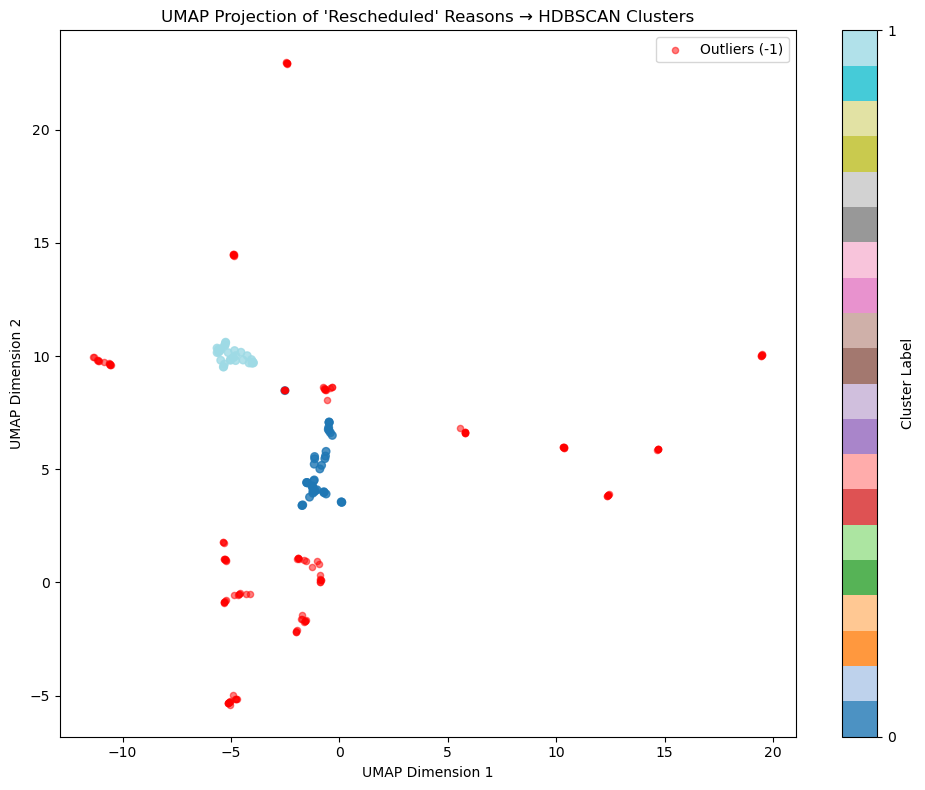

In [15]:
plt.figure(figsize=(10, 8))

mask_out = labels_del == -1
mask_in  = ~mask_out

sc = plt.scatter(
    umap_del[mask_in, 0], 
    umap_del[mask_in, 1], 
    c=labels_del[mask_in],      
    cmap='tab20',               
    s=30,                       
    alpha=0.8                   
)

plt.scatter(
    umap_del[mask_out, 0],
    umap_del[mask_out, 1],
    color='red',
    s=20,                       
    alpha=0.5,                  
    label='Outliers (-1)'
)

plt.legend(loc='upper right')
plt.title("UMAP Projection of 'Rescheduled' Reasons → HDBSCAN Clusters")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

valid_ticks = np.unique(labels_del[mask_in])
cbar = plt.colorbar(sc, ticks=valid_ticks)
cbar.set_label("Cluster Label")

plt.tight_layout()
plt.savefig("Images/Umap_Rescheduled.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

### Step 4: Generate a human‐readable “meaning” for each Rescheduled cluster

In [16]:
def top_keywords(texts, top_n=5):
    min_docs = 2 if len(texts) >= 2 else 1
    
    vec = TfidfVectorizer(
        max_df=0.8,       
        min_df=min_docs,  
        stop_words='english'
    )
    X = vec.fit_transform(texts)
    scores = np.asarray(X.sum(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    top_ix = scores.argsort()[::-1][:top_n]
    return [terms[i] for i in top_ix]

def summarize_clusters(df_isolated, embedder, top_n_kw=5):
    print("--- Final Intelligent Cluster Summary ---")
    
    for cl in sorted(df_isolated['Cluster'].unique()):
        docs = df_isolated[df_isolated['Cluster'] == cl]['Inv_Progress Driver'].dropna().astype(str).tolist()
        docs = [d for d in docs if d.strip() != ''] 
        
        if not docs:
            continue
            
        n = len(docs)
        
        if cl < 0:
            print(f"\n[ Outliers (-1) | Total: {n} sentences ]")
            print("Examples of uncategorized sentences:")
            for ex in docs[:3]:
                print(f"  - \"{ex}\"")
            continue

        kws = top_keywords(docs, top_n=top_n_kw)

        embs = embedder.encode(docs, show_progress_bar=False)
        centroid = embs.mean(axis=0)
        idx = np.linalg.norm(embs - centroid, axis=1).argmin()
        rep = docs[idx]

        print(f"\n[ Cluster {cl} | Total: {n} sentences ]")
        print(f"  • Keywords: {', '.join(kws)}")
        print(f"  • Representative: \"{rep}\"")

summarize_clusters(df_Rescheduled, embedder, top_n_kw=5)

--- Final Intelligent Cluster Summary ---

[ Outliers (-1) | Total: 139 sentences ]
Examples of uncategorized sentences:
  - "Feasibility study is expected to be launched."
  - "Investment depending on Visaginas NPP construction time."
  - "Investment rescheduled as a result of changes in planning data inputs (demand reduction and projects of new thermal units are in stand by)"

[ Cluster 0 | Total: 41 sentences ]
  • Keywords: commissioning, project, date, investment, new
  • Representative: "Adjustment of commissioning date to 2027 during the project planning process."

[ Cluster 1 | Total: 33 sentences ]
  • Keywords: investment, project, new, rescheduled, development
  • Representative: "Investment rescheduled due to, and in accordance with, delayed development of new power plant, as considered in the Master Plan 2020 in progress"


In [17]:
output_path_rescheduled = "Results/Clusters_Rescheduled_HDBSCAN.xlsx"
df_Rescheduled.to_excel(output_path_rescheduled, index=False)